<a href="https://colab.research.google.com/github/KeshavFTW099/ArtificalAdvanced_NeuralNetworks/blob/main/VGG_16_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

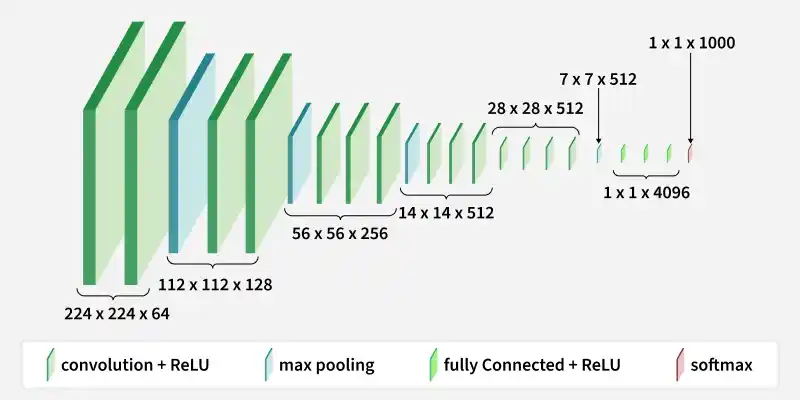

**Implementation of VGG-16 Architecture using TensorFlow/Keras**

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, models, layers, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
import numpy as np
import pandas as pd

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Convert training and testing images to float32
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("X Train Shape :", x_train.shape)
print("X Test Shape  :", x_test.shape)
print("Y Train Shape :", y_train.shape)
print("Y Test Shape  :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 693s 4us/step
X Train Shape : (50000, 32, 32, 3)
X Test Shape  : (10000, 32, 32, 3)
Y Train Shape : (50000, 1)
Y Test Shape  : (10000, 1)



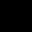
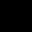
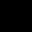
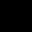
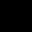
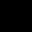
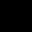
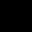
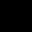
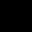


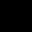
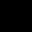
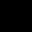
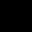
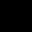
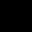
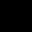
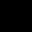
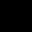
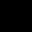


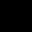
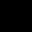
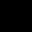
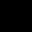
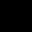
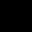
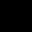
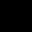
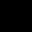
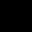


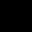
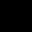
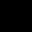
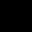
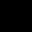
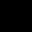
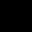
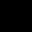
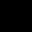
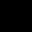

Number of Labels : 10
Image Size : 32


In [12]:
import ipyplot

# Display training images
ipyplot.plot_images(
    x_train,
    max_images=10,
    img_width=120
)

# Display testing images
ipyplot.plot_images(
    x_test,
    max_images=10,
    img_width=120
)

# Number of classes
num_labels = len(np.unique(y_train))
print("Number of Labels :", num_labels)

# Image size
image_size = x_train.shape[1]
print("Image Size :", image_size)

# Input shape
input_shape = (image_size, image_size, 3)



In [13]:
# Normalize training and testing images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical form
y_train_cat = to_categorical(y_train, num_labels)
y_test_cat = to_categorical(y_test, num_labels)

# Training parameters
batch_size = 128
epochs = 2
validation_split = 0.3
classes = num_labels

# Adagrad optimizer
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.6)

# Create Sequential model
model = models.Sequential()

# Convolution layer
model.add(layers.Conv2D(
    6,
    (5,5),
    activation='tanh',
    input_shape=input_shape
))

CREATING MODEL ARCHITECTURE

In [14]:
model = models.Sequential()

model.add(layers.Conv2D(6,(5,5),activation='tanh',input_shape=input_shape))
model.add(layers.AveragePooling2D((2,2),strides=(2,2)))

model.add(layers.Conv2D(16,(5,5),activation='tanh'))
model.add(layers.AveragePooling2D((2,2),strides=(2,2)))

model.add(layers.Conv2D(120,(5,5),activation='tanh'))

model.add(layers.Flatten())

model.add(layers.Dropout(0.5))
model.add(layers.Dense(84,activation='tanh'))

model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

In [15]:
# TensorBoard callback
log_dir = "logs"

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)


In [ ]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train,
    y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[tensorboard_callback]
)

# Print accuracy
print("Accuracy :", history.history['accuracy'][-1] * 100, "%")

Epoch 1/2
367/391 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.0976 - loss: 6.6300